In [24]:
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split

In [25]:
titanic = sns.load_dataset("titanic")

In [26]:
titanic.head()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [27]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [28]:
#missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy = "median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy = "most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])


In [29]:
#encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [30]:
X = titanic[features]
y = titanic[target]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [34]:
X_test.head()

,pclass,sex,fare,embarked,age
709,3,1,15.2458,0,28.0
439,2,1,10.5000,2,31.0
840,3,1,7.9250,2,20.0
720,2,0,33.0000,2,6.0
39,3,0,11.2417,0,14.0


In [35]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("accuracy: ", accuracy_score(y_test, y_pred))

accuracy:  0.7597765363128491


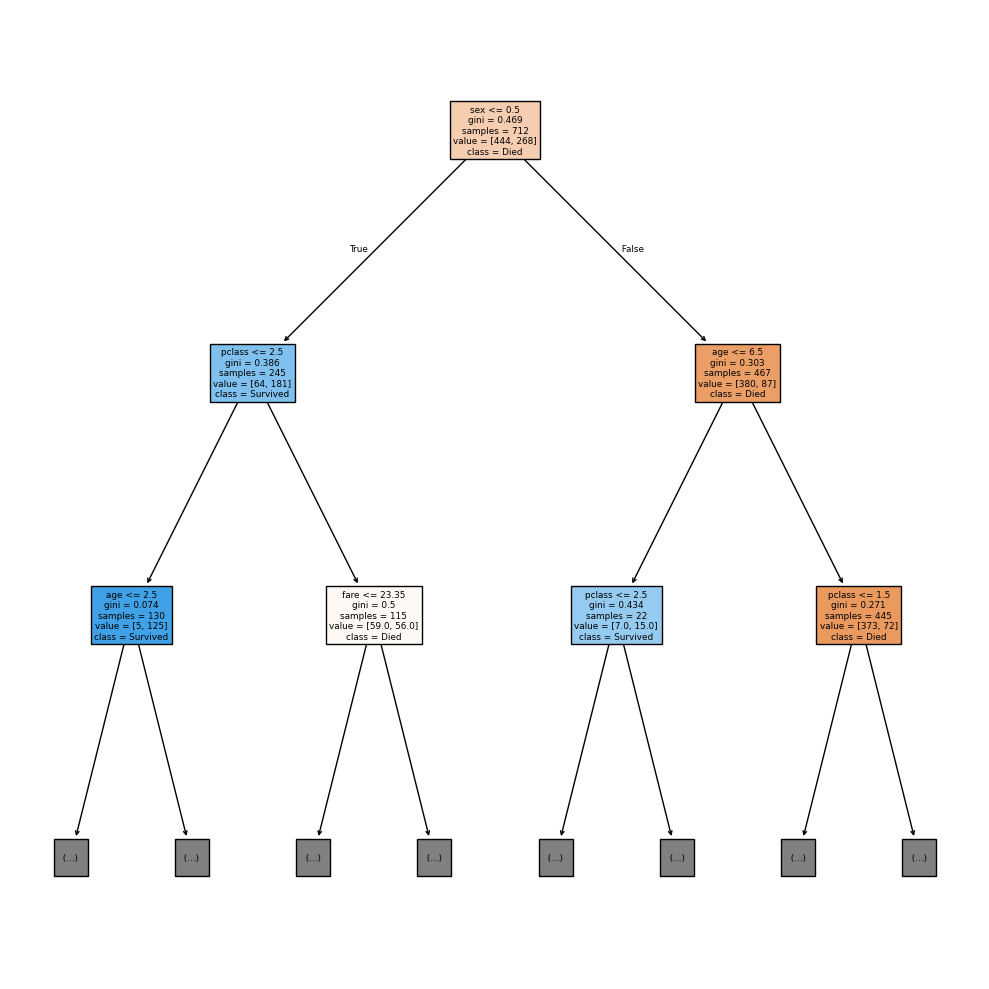

In [39]:
from sklearn.tree import plot_tree

plt.figure(figsize = (10,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True,
    max_depth = 2
    
)

plt.tight_layout()
plt.show()

# Decision Tree with pre-

for depth = 1, accuracy = 0.7821229050279329


<Figure size 640x480 with 0 Axes>

for depth = 2, accuracy = 0.7653631284916201


<Figure size 640x480 with 0 Axes>

for depth = 3, accuracy = 0.7988826815642458


<Figure size 640x480 with 0 Axes>

for depth = 4, accuracy = 0.7988826815642458


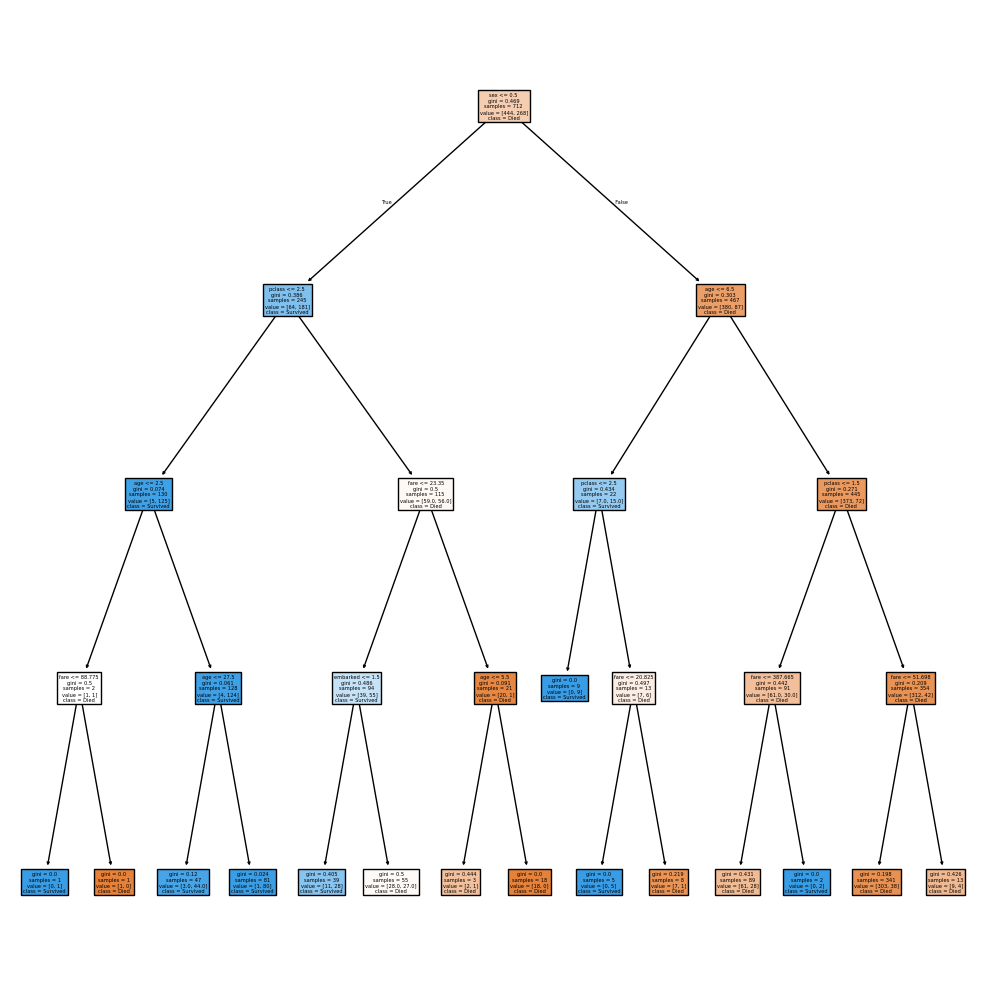

for depth = 5, accuracy = 0.7988826815642458


<Figure size 640x480 with 0 Axes>

for depth = 6, accuracy = 0.7988826815642458


<Figure size 640x480 with 0 Axes>

for depth = 7, accuracy = 0.7877094972067039


<Figure size 640x480 with 0 Axes>

for depth = 8, accuracy = 0.7932960893854749


<Figure size 640x480 with 0 Axes>

for depth = 9, accuracy = 0.8044692737430168


<Figure size 640x480 with 0 Axes>

for depth = 10, accuracy = 0.7877094972067039


<Figure size 640x480 with 0 Axes>

In [51]:
max_depth = [1,2,3,4,5,6 , 7, 8 ,9 ,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")

    if depth == 4:
        plt.figure(figsize = (10,10))
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True,
    
    )

    plt.tight_layout()
    plt.show()

In [46]:
min_samples_splits = [5,10,15,20,25,30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)
    print(f"for depth = {depth}, accuracy = {acc}")
    
    

for depth = 7, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.7988826815642458
for depth = 7, accuracy = 0.7932960893854749
for depth = 7, accuracy = 0.7932960893854749


# Decision Tree with post-pruning

In [52]:
full_tree = DecisionTreeClassifier(random_state = 42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [ ]:
# train our model for all alphas
